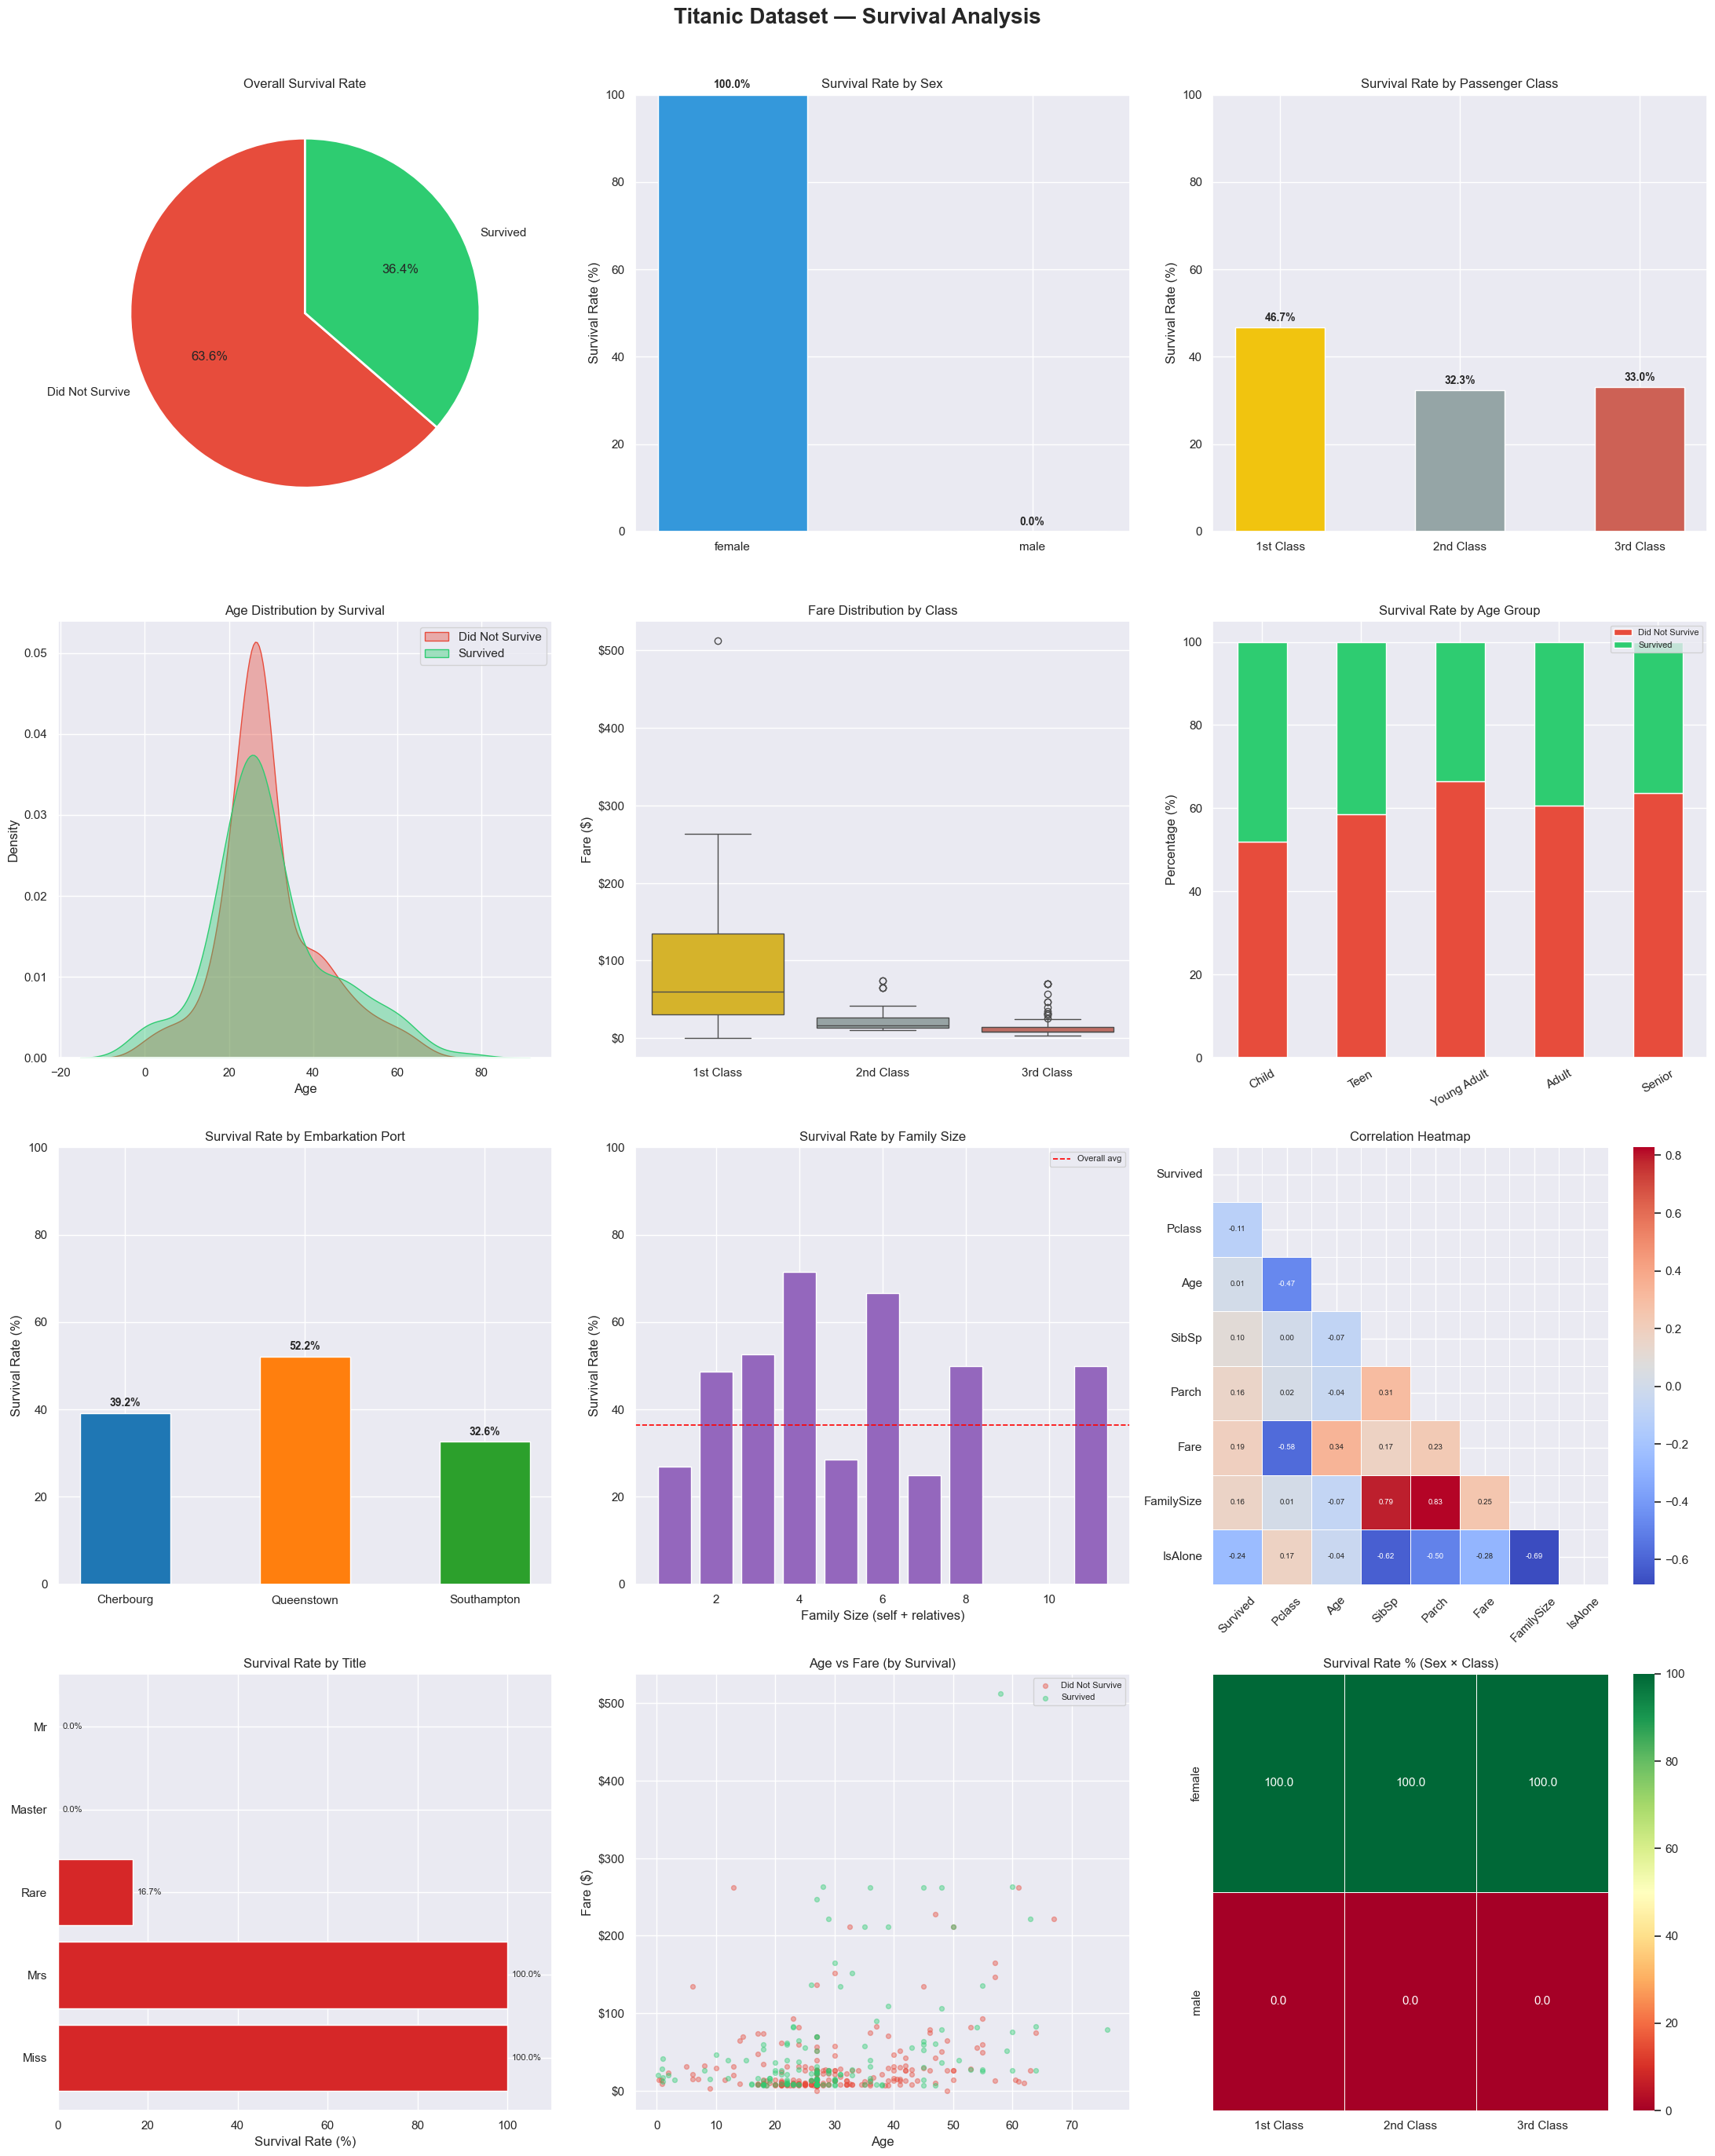

In [2]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")



df = pd.read_csv("Titanic.csv")

# Fill missing values
df["Age"]      = df["Age"].fillna(df["Age"].median())
df["Fare"]     = df["Fare"].fillna(df["Fare"].median())
df["Cabin"]    = df["Cabin"].apply(lambda x: x[0] if pd.notna(x) else "Unknown")
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Derived features
df["AgeGroup"] = pd.cut(df["Age"], bins=[0,12,18,35,60,100],
                         labels=["Child","Teen","Young Adult","Adult","Senior"])
df["FareBand"] = pd.qcut(df["Fare"], q=4,
                          labels=["Low","Medium","High","Very High"])
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"]    = (df["FamilySize"] == 1).astype(int)
df["Title"]      = df["Name"].str.extract(r' ([A-Za-z]+)\.', expand=False)
df["Title"]      = df["Title"].replace(
    ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
df["Title"]      = df["Title"].replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})

PCLASS_MAP = {1: "1st Class", 2: "2nd Class", 3: "3rd Class"}
df["PclassLabel"] = df["Pclass"].map(PCLASS_MAP)

SURVIVED_COLORS = ["#e74c3c", "#2ecc71"]
COLORS = sns.color_palette("tab10")
sns.set_theme(style="darkgrid", palette="muted")

# ─── FIGURE ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 28))
fig.suptitle("Titanic Dataset — Survival Analysis", fontsize=20, fontweight="bold", y=0.98)

# 1 · Overall Survival (Pie)
ax1 = fig.add_subplot(4, 3, 1)
counts = df["Survived"].value_counts()
ax1.pie(counts, labels=["Did Not Survive", "Survived"],
        colors=SURVIVED_COLORS, autopct="%1.1f%%", startangle=90,
        wedgeprops=dict(edgecolor="white", linewidth=2))
ax1.set_title("Overall Survival Rate")

# 2 · Survival by Sex
ax2 = fig.add_subplot(4, 3, 2)
sex_surv = df.groupby("Sex")["Survived"].mean() * 100
bars = ax2.bar(sex_surv.index, sex_surv.values,
               color=["#3498db", "#e91e8c"], edgecolor="white", width=0.5)
ax2.set_title("Survival Rate by Sex")
ax2.set_ylabel("Survival Rate (%)")
ax2.set_ylim(0, 100)
for bar, val in zip(bars, sex_surv.values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 1.5, f"{val:.1f}%",
             ha="center", fontsize=10, fontweight="bold")

# 3 · Survival by Pclass
ax3 = fig.add_subplot(4, 3, 3)
pclass_surv = df.groupby("PclassLabel")["Survived"].mean() * 100
order3 = ["1st Class", "2nd Class", "3rd Class"]
vals = [pclass_surv[c] for c in order3]
bars3 = ax3.bar(order3, vals, color=["#f1c40f","#95a5a6","#cd6155"], edgecolor="white", width=0.5)
ax3.set_title("Survival Rate by Passenger Class")
ax3.set_ylabel("Survival Rate (%)")
ax3.set_ylim(0, 100)
for bar, val in zip(bars3, vals):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 1.5, f"{val:.1f}%",
             ha="center", fontsize=10, fontweight="bold")

# 4 · Age Distribution by Survival (KDE)
ax4 = fig.add_subplot(4, 3, 4)
for surv, label, color in zip([0,1], ["Did Not Survive","Survived"], SURVIVED_COLORS):
    sns.kdeplot(df[df["Survived"]==surv]["Age"], ax=ax4, label=label,
                fill=True, alpha=0.4, color=color)
ax4.set_title("Age Distribution by Survival")
ax4.set_xlabel("Age")
ax4.legend()

# 5 · Fare Distribution by Class (Box)
ax5 = fig.add_subplot(4, 3, 5)
sns.boxplot(data=df, x="PclassLabel", y="Fare", order=order3,
            palette=["#f1c40f","#95a5a6","#cd6155"], ax=ax5)
ax5.set_title("Fare Distribution by Class")
ax5.set_xlabel("")
ax5.set_ylabel("Fare ($)")
ax5.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"${x:.0f}"))

# 6 · Survival by Age Group (Stacked Bar)
ax6 = fig.add_subplot(4, 3, 6)
ag = df.groupby("AgeGroup")["Survived"].value_counts(normalize=True).unstack() * 100
ag.plot(kind="bar", stacked=True, ax=ax6, color=SURVIVED_COLORS, edgecolor="white")
ax6.set_title("Survival Rate by Age Group")
ax6.set_ylabel("Percentage (%)")
ax6.set_xlabel("")
ax6.tick_params(axis="x", rotation=30)
ax6.legend(["Did Not Survive","Survived"], loc="upper right", fontsize=8)

# 7 · Survival by Embarkation Port
ax7 = fig.add_subplot(4, 3, 7)
port_map = {"S":"Southampton","C":"Cherbourg","Q":"Queenstown"}
df["EmbarkedFull"] = df["Embarked"].map(port_map)
emb_surv = df.groupby("EmbarkedFull")["Survived"].mean() * 100
bars7 = ax7.bar(emb_surv.index, emb_surv.values,
                color=[COLORS[0],COLORS[1],COLORS[2]], edgecolor="white", width=0.5)
ax7.set_title("Survival Rate by Embarkation Port")
ax7.set_ylabel("Survival Rate (%)")
ax7.set_ylim(0, 100)
for bar, val in zip(bars7, emb_surv.values):
    ax7.text(bar.get_x() + bar.get_width()/2, val + 1.5, f"{val:.1f}%",
             ha="center", fontsize=10, fontweight="bold")

# 8 · Family Size vs Survival
ax8 = fig.add_subplot(4, 3, 8)
fam_surv = df.groupby("FamilySize")["Survived"].mean() * 100
ax8.bar(fam_surv.index, fam_surv.values, color=COLORS[4], edgecolor="white")
ax8.set_title("Survival Rate by Family Size")
ax8.set_xlabel("Family Size (self + relatives)")
ax8.set_ylabel("Survival Rate (%)")
ax8.set_ylim(0, 100)
ax8.axhline(df["Survived"].mean()*100, color="red", linestyle="--", linewidth=1.2, label="Overall avg")
ax8.legend(fontsize=8)

# 9 · Correlation Heatmap
ax9 = fig.add_subplot(4, 3, 9)
num_cols = ["Survived","Pclass","Age","SibSp","Parch","Fare","FamilySize","IsAlone"]
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax9, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, annot_kws={"size":7})
ax9.set_title("Correlation Heatmap")
ax9.tick_params(axis="x", rotation=45)
ax9.tick_params(axis="y", rotation=0)

# 10 · Survival by Title
ax10 = fig.add_subplot(4, 3, 10)
title_surv = df.groupby("Title")["Survived"].mean().sort_values(ascending=False) * 100
bars10 = ax10.barh(title_surv.index, title_surv.values, color=COLORS[3], edgecolor="white")
ax10.set_title("Survival Rate by Title")
ax10.set_xlabel("Survival Rate (%)")
ax10.set_xlim(0, 110)
for bar, val in zip(bars10, title_surv.values):
    ax10.text(val + 1, bar.get_y() + bar.get_height()/2, f"{val:.1f}%",
              va="center", fontsize=8)

# 11 · Fare vs Age Scatter (colored by survival)
ax11 = fig.add_subplot(4, 3, 11)
for surv, label, color in zip([0,1], ["Did Not Survive","Survived"], SURVIVED_COLORS):
    sub = df[df["Survived"] == surv]
    ax11.scatter(sub["Age"], sub["Fare"], alpha=0.4, s=18, color=color, label=label)
ax11.set_title("Age vs Fare (by Survival)")
ax11.set_xlabel("Age")
ax11.set_ylabel("Fare ($)")
ax11.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"${x:.0f}"))
ax11.legend(fontsize=8)

# 12 · Sex × Class Survival Heatmap
ax12 = fig.add_subplot(4, 3, 12)
pivot = df.pivot_table(values="Survived", index="Sex", columns="PclassLabel", aggfunc="mean") * 100
pivot = pivot[order3]
sns.heatmap(pivot, ax=ax12, annot=True, fmt=".1f", cmap="RdYlGn",
            linewidths=0.5, annot_kws={"size":11}, vmin=0, vmax=100)
ax12.set_title("Survival Rate % (Sex × Class)")
ax12.set_xlabel("")
ax12.set_ylabel("")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [ ]:
import os, sys
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from dash import Dash, dcc, html, Input, Output
import plotly.express as px
import plotly.graph_objects as go



df = pd.read_csv("Titanic.csv")
df["Age"]      = df["Age"].fillna(df["Age"].median())
df["Fare"]     = df["Fare"].fillna(df["Fare"].median())
df["Cabin"]    = df["Cabin"].apply(lambda x: x[0] if pd.notna(x) else "Unknown")
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df["AgeGroup"]     = pd.cut(df["Age"], bins=[0,12,18,35,60,100],
                              labels=["Child","Teen","Young Adult","Adult","Senior"])
df["FamilySize"]   = df["SibSp"] + df["Parch"] + 1
df["IsAlone"]      = (df["FamilySize"] == 1).astype(int)
df["Title"]        = df["Name"].str.extract(r' ([A-Za-z]+)\.', expand=False)
df["Title"]        = df["Title"].replace(
    ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
df["Title"]        = df["Title"].replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})
df["PclassLabel"]  = df["Pclass"].map({1:"1st Class", 2:"2nd Class", 3:"3rd Class"})
df["EmbarkedFull"] = df["Embarked"].map({"S":"Southampton","C":"Cherbourg","Q":"Queenstown"})
df["SurvivedLabel"]= df["Survived"].map({0:"Did Not Survive", 1:"Survived"})

PCLASS_ORDER = ["1st Class","2nd Class","3rd Class"]
AGE_ORDER    = ["Child","Teen","Young Adult","Adult","Senior"]
SURV_COLORS  = {"Survived":"#2ecc71", "Did Not Survive":"#e74c3c"}

SEXES   = ["All"] + sorted(df["Sex"].unique().tolist())
CLASSES = ["All"] + PCLASS_ORDER
PORTS   = ["All"] + sorted(df["EmbarkedFull"].unique().tolist())

# ─── APP ──────────────────────────────────────────────────────────────────────
app = Dash(__name__)

def kpi_card(title, value, color):
    return html.Div(
        style={"backgroundColor": color, "borderRadius": "10px", "padding": "15px 25px",
               "color": "white", "textAlign": "center", "minWidth": "150px",
               "boxShadow": "2px 2px 6px rgba(0,0,0,0.15)"},
        children=[
            html.P(title,  style={"margin": 0, "fontSize": "13px", "opacity": 0.9}),
            html.H3(value, style={"margin": "5px 0 0 0"}),
        ]
    )

app.layout = html.Div(
    style={"fontFamily": "Arial", "backgroundColor": "#f0f2f5", "padding": "20px"},
    children=[
        html.H1("Titanic Survival Analysis Dashboard",
                style={"textAlign": "center", "color": "#2c3e50", "marginBottom": "10px"}),

        html.Div(
            style={"display": "flex", "gap": "30px", "marginBottom": "20px",
                   "justifyContent": "center", "flexWrap": "wrap"},
            children=[
                html.Div([html.Label("Sex", style={"fontWeight": "bold"}),
                          dcc.Dropdown(id="sex-filter",
                                       options=[{"label": s, "value": s} for s in SEXES],
                                       value="All", clearable=False, style={"width": "160px"})]),
                html.Div([html.Label("Passenger Class", style={"fontWeight": "bold"}),
                          dcc.Dropdown(id="class-filter",
                                       options=[{"label": c, "value": c} for c in CLASSES],
                                       value="All", clearable=False, style={"width": "180px"})]),
                html.Div([html.Label("Embarkation Port", style={"fontWeight": "bold"}),
                          dcc.Dropdown(id="port-filter",
                                       options=[{"label": p, "value": p} for p in PORTS],
                                       value="All", clearable=False, style={"width": "180px"})]),
            ]
        ),

        html.Div(id="kpi-cards",
                 style={"display": "flex", "gap": "20px", "marginBottom": "20px",
                        "justifyContent": "center", "flexWrap": "wrap"}),

        html.Div(style={"display": "flex", "gap": "15px", "marginBottom": "15px"}, children=[
            dcc.Graph(id="survival-pie",   style={"flex": 1}),
            dcc.Graph(id="survival-sex",   style={"flex": 1}),
            dcc.Graph(id="survival-class", style={"flex": 1}),
        ]),
        html.Div(style={"display": "flex", "gap": "15px", "marginBottom": "15px"}, children=[
            dcc.Graph(id="age-hist",       style={"flex": 2}),
            dcc.Graph(id="fare-box",       style={"flex": 1}),
        ]),
        html.Div(style={"display": "flex", "gap": "15px", "marginBottom": "15px"}, children=[
            dcc.Graph(id="agegroup-bar",   style={"flex": 1}),
            dcc.Graph(id="family-bar",     style={"flex": 1}),
            dcc.Graph(id="title-bar",      style={"flex": 1}),
        ]),
        html.Div(style={"display": "flex", "gap": "15px"}, children=[
            dcc.Graph(id="scatter-age-fare",  style={"flex": 2}),
            dcc.Graph(id="sex-class-heatmap", style={"flex": 1}),
        ]),
    ]
)

# ─── CALLBACK ─────────────────────────────────────────────────────────────────
@app.callback(
    Output("kpi-cards",          "children"),
    Output("survival-pie",       "figure"),
    Output("survival-sex",       "figure"),
    Output("survival-class",     "figure"),
    Output("age-hist",           "figure"),
    Output("fare-box",           "figure"),
    Output("agegroup-bar",       "figure"),
    Output("family-bar",         "figure"),
    Output("title-bar",          "figure"),
    Output("scatter-age-fare",   "figure"),
    Output("sex-class-heatmap",  "figure"),
    Input("sex-filter",   "value"),
    Input("class-filter", "value"),
    Input("port-filter",  "value"),
)
def update(sex, pclass, port):
    d = df.copy()
    if sex    != "All": d = d[d["Sex"]          == sex]
    if pclass != "All": d = d[d["PclassLabel"]  == pclass]
    if port   != "All": d = d[d["EmbarkedFull"] == port]

    if len(d) == 0:
        empty = go.Figure().update_layout(title="No data for selected filters")
        empty_cards = [kpi_card("No Data", "—", "#95a5a6")]
        return (empty_cards, empty, empty, empty, empty, empty,
                empty, empty, empty, empty, empty)

    total     = len(d)
    survived  = int(d["Survived"].sum())
    surv_rate = survived / total * 100
    avg_age   = d["Age"].mean()
    avg_fare  = d["Fare"].mean()

    cards = [
        kpi_card("Total Passengers", f"{total}",           "#3498db"),
        kpi_card("Survived",         f"{survived}",         "#2ecc71"),
        kpi_card("Survival Rate",    f"{surv_rate:.1f}%",   "#9b59b6"),
        kpi_card("Avg Age",          f"{avg_age:.1f} yrs",  "#e67e22"),
        kpi_card("Avg Fare",         f"${avg_fare:.1f}",    "#1abc9c"),
    ]

    # 1 · Survival pie
    counts = d["SurvivedLabel"].value_counts().reset_index()
    counts.columns = ["Status", "Count"]
    fig_pie = px.pie(counts, names="Status", values="Count", title="Overall Survival",
                     hole=0.4, color="Status", color_discrete_map=SURV_COLORS,
                     template="plotly_white")

    # 2 · Survival by sex
    sex_s = d.groupby("Sex")["Survived"].mean().reset_index()
    sex_s["Rate"] = (sex_s["Survived"] * 100).round(1)
    fig_sex = px.bar(sex_s, x="Sex", y="Rate", title="Survival Rate by Sex",
                     color="Sex", color_discrete_sequence=["#3498db","#e91e8c"],
                     template="plotly_white", text=sex_s["Rate"].map("{:.1f}%".format))
    fig_sex.update_traces(textposition="outside")
    fig_sex.update_yaxes(range=[0, 110], title="Survival Rate (%)")
    fig_sex.update_layout(showlegend=False)

    # 3 · Survival by class
    avail_cls = [c for c in PCLASS_ORDER if c in d["PclassLabel"].unique()]
    cls_s = d.groupby("PclassLabel")["Survived"].mean().reindex(avail_cls).reset_index()
    cls_s["Rate"] = (cls_s["Survived"] * 100).round(1)
    fig_cls = px.bar(cls_s, x="PclassLabel", y="Rate", title="Survival Rate by Class",
                     color="PclassLabel",
                     color_discrete_sequence=["#f1c40f","#95a5a6","#cd6155"],
                     template="plotly_white", text=cls_s["Rate"].map("{:.1f}%".format),
                     category_orders={"PclassLabel": avail_cls})
    fig_cls.update_traces(textposition="outside")
    fig_cls.update_yaxes(range=[0, 110], title="Survival Rate (%)")
    fig_cls.update_layout(showlegend=False, xaxis_title="")

    # 4 · Age histogram (no scipy needed)
    fig_age = px.histogram(d, x="Age", color="SurvivedLabel", barmode="overlay",
                           color_discrete_map=SURV_COLORS, opacity=0.7, nbins=30,
                           title="Age Distribution by Survival",
                           labels={"SurvivedLabel": "Status"},
                           template="plotly_white")
    fig_age.update_layout(legend=dict(orientation="h"), bargap=0.05)

    # 5 · Fare box by class
    fig_fare = px.box(d, x="PclassLabel", y="Fare",
                      category_orders={"PclassLabel": avail_cls},
                      color="PclassLabel",
                      color_discrete_sequence=["#f1c40f","#95a5a6","#cd6155"],
                      title="Fare Distribution by Class", template="plotly_white")
    fig_fare.update_layout(showlegend=False, xaxis_title="")

    # 6 · Age group stacked bar
    avail_ag = [a for a in AGE_ORDER if a in d["AgeGroup"].unique()]
    ag = d.groupby(["AgeGroup","SurvivedLabel"]).size().reset_index(name="Count")
    ag_total = ag.groupby("AgeGroup")["Count"].transform("sum")
    ag["Pct"] = (ag["Count"] / ag_total * 100).round(1)
    fig_ag = px.bar(ag, x="AgeGroup", y="Pct", color="SurvivedLabel",
                    color_discrete_map=SURV_COLORS, title="Survival % by Age Group",
                    template="plotly_white",
                    category_orders={"AgeGroup": avail_ag},
                    labels={"Pct":"Percentage (%)","SurvivedLabel":"Status"})
    fig_ag.update_layout(barmode="stack", xaxis_title="", legend=dict(orientation="h"))

    # 7 · Family size bar
    fam_s = d.groupby("FamilySize")["Survived"].mean().reset_index()
    fam_s["Rate"] = (fam_s["Survived"] * 100).round(1)
    avg_line = surv_rate
    fig_fam = px.bar(fam_s, x="FamilySize", y="Rate", title="Survival Rate by Family Size",
                     color="Rate", color_continuous_scale="RdYlGn",
                     range_color=[0, 100], template="plotly_white")
    fig_fam.add_hline(y=avg_line, line_dash="dash", line_color="red",
                      annotation_text=f"Avg {avg_line:.1f}%")
    fig_fam.update_layout(xaxis_title="Family Size", yaxis_title="Survival Rate (%)",
                          coloraxis_showscale=False)

    # 8 · Title bar
    title_s = d.groupby("Title")["Survived"].mean().reset_index()
    title_s["Rate"] = (title_s["Survived"] * 100).round(1)
    title_s = title_s.sort_values("Rate", ascending=True)
    fig_title = px.bar(title_s, x="Rate", y="Title", orientation="h",
                       title="Survival Rate by Title", template="plotly_white",
                       color="Rate", color_continuous_scale="RdYlGn", range_color=[0,100])
    fig_title.update_layout(xaxis_title="Survival Rate (%)", yaxis_title="",
                            coloraxis_showscale=False)

    # 9 · Scatter Age vs Fare
    fig_scat = px.scatter(d, x="Age", y="Fare", color="SurvivedLabel",
                          color_discrete_map=SURV_COLORS,
                          symbol="PclassLabel", opacity=0.6,
                          title="Age vs Fare (colored by Survival)",
                          template="plotly_white",
                          labels={"SurvivedLabel":"Status","PclassLabel":"Class"})
    fig_scat.update_layout(legend=dict(orientation="h"))

    # 10 · Sex × Class heatmap
    avail_sex = sorted(d["Sex"].unique().tolist())
    pivot = d.pivot_table(values="Survived", index="Sex",
                          columns="PclassLabel", aggfunc="mean")
    pivot = pivot.reindex(columns=avail_cls) * 100
    fig_heat = px.imshow(pivot.round(1), text_auto=True,
                         color_continuous_scale="RdYlGn", zmin=0, zmax=100,
                         title="Survival Rate % (Sex × Class)",
                         template="plotly_white")
    fig_heat.update_layout(xaxis_title="", yaxis_title="")

    return (cards, fig_pie, fig_sex, fig_cls, fig_age, fig_fare,
            fig_ag, fig_fam, fig_title, fig_scat, fig_heat)


if __name__ == "__main__":
    print("Dashboard running at  http://127.0.0.1:8050")
    app.run(debug=False)

Dashboard running at  http://127.0.0.1:8050
